In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,BatchNormalization

In [14]:
dir="D:\Deep_learning\cat_vs_dog _images\PetImages"

In [15]:
# TRAINING DATASET (80% images)
train_ds = keras.utils.image_dataset_from_directory(
    directory=dir,               #  single PetImages folder path
    validation_split=0.2,        # 20% data 
    subset="training",           #  80% training data #subset is used to tell tensor flow which part of the split you want to use 
    seed=123,                  
    labels='inferred', # tesnosr flow will automacticlly assign labels based on foler names 
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

# VALIDATION / TESTING DATASET (20% images)
validation_ds = keras.utils.image_dataset_from_directory(
    directory=dir,               # Same PetImages folder
    validation_split=0.2,        # it simply means keeps 20 percent for training gv
    subset="validation",         # 20% test data 
    seed=123,                    
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 396 files belonging to 2 classes.
Using 317 files for training.
Found 396 files belonging to 2 classes.
Using 79 files for validation.


In [16]:
import os
import tensorflow as tf

# 1. Update this to the path where your raw images are stored
dataset_dir = "D:\Deep_learning\cat_vs_dog _images\PetImages" 

print("Scanning dataset for corrupted images...")

corrupted_files = []

for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        # Check only common image extensions to avoid text files, etc.
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            file_path = os.path.join(root, file)
            
            try:
                # Read the raw bytes
                image_contents = tf.io.read_file(file_path)
                # Attempt to decode it exactly as the tf.data pipeline does
                _ = tf.image.decode_image(image_contents)
                
            except tf.errors.InvalidArgumentError as e:
                print(f"\n⚠️ Found corrupted image: {file_path}")
                corrupted_files.append(file_path)

print(f"\nScan complete. Found {len(corrupted_files)} corrupted files.")

#2. Uncomment the lines below if you want the script to automatically delete them
for bad_file in corrupted_files:
    os.remove(bad_file)
    print(f"Deleted: {bad_file}")

Scanning dataset for corrupted images...

Scan complete. Found 0 corrupted files.


In [17]:
# Normalize
def process(image,label):
    image = tf.cast(image/255. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [6]:
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add((BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add((BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add((BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1)
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.1)
model.add(Dense(1,activation='sigmoid'))

C:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,541,893 (169.91 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 29,694,596 (113.28 MB)

In [19]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.8707 - loss: 0.6489 - val_accuracy: 0.5949 - val_loss: 0.7153
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.9054 - loss: 0.2814 - val_accuracy: 0.5443 - val_loss: 0.9554
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9653 - loss: 0.1219 - val_accuracy: 0.5570 - val_loss: 1.2681
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.9811 - loss: 0.0497 - val_accuracy: 0.5443 - val_loss: 1.6970
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 0.5190 - val_loss: 2.2860
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 0.5190 - val_loss: 2.6431
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 1.0000 - loss: 5.9882e-04 - val_accuracy: 0.5443 - val_loss: 2.9017
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 1.0000 - loss: 2.6387e-04 - val_accuracy: 0.5570 - v

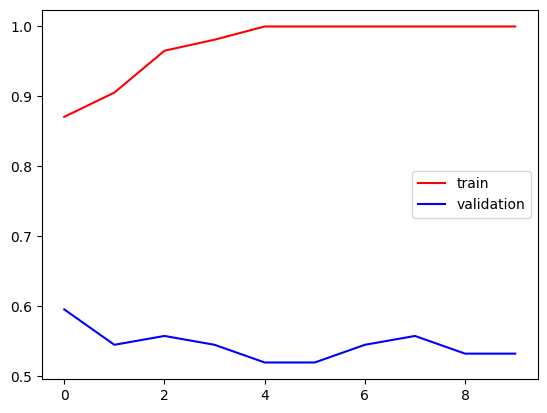

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

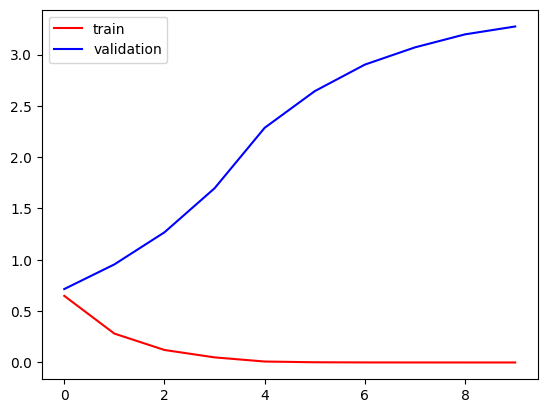

In [22]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()